In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

In [2]:
Estocastica = np.load('Estocastica/F_Estocastica_deltas.npy', allow_pickle=True).item()
Determinista1_Best = np.load('Determinista_1/F_Deterministic_deltar_Best.npy', allow_pickle=True).item()
Determinista1_Worst = np.load('Determinista_1/F_Deterministic_deltar_Worst.npy', allow_pickle=True).item()
Determinista2_Best = np.load('Determinista_2/F_Deterministic_deltar_enlace_Best.npy', allow_pickle=True).item()
Determinista2_Worst = np.load('Determinista_2/F_Deterministic_deltar_enlace_Worst.npy', allow_pickle=True).item()
Edge_B_High = np.load('Edge_B/F_edge_deltar_high_betweenness.npy', allow_pickle=True).item()
Edge_B_Low = np.load('Edge_B/F_edge_deltar_low_betweenness.npy', allow_pickle=True).item()
Edge_Ponderada_High = np.load('Edge_Ponderada/F_edge_deltar_high_betweenness.npy', allow_pickle=True).item()
Edge_Ponderada_Low = np.load('Edge_Ponderada/F_edge_deltar_low_betweenness.npy', allow_pickle=True).item()
Topo_Best = np.load('Topo_1/F_inter_first_best.npy', allow_pickle=True).item()
Topo_Worst = np.load('Topo_1/F_inter_first_worst.npy', allow_pickle=True).item()


## TODAS

In [9]:
# -----------------------------------DATOS--------------------------------------

datasets = {
    'Estocástica':           Estocastica,
    #'Determinista 1 Best':   Determinista1_Best,
    'Determinista por pasos':  Determinista1_Worst,
    #'Determinista 2 Best':   Determinista2_Best,
    'Determinista completa':  Determinista2_Worst,
    'EBC simple':           Edge_B_High,
    #'Edge B Low':            Edge_B_Low,
    'EBC Ponderada':   Edge_Ponderada_High,
    #'Edge Ponderada Low':    Edge_Ponderada_Low,
    #'Topo Best':             Topo_Best,
    'Comunidades':            Topo_Worst,
}

estilos = {
    # Estocástica — referencia en negro sólido grueso
    'Estocástica':           dict(color='black',         linestyle='-',               linewidth=2.5, marker='None'),

    # Determinista 1 — azules (oscuro / claro)
    'Determinista 1 Best':   dict(color='#1a6faf',       linestyle='--',              linewidth=2.5, marker='o',  markersize=5, markevery=2000),
    'Determinista por pasos':  dict(color='#7ab8d9',       linestyle=':',               linewidth=2.5, marker='s',  markersize=5, markevery=2000),

    # Determinista 2 — rojos (oscuro / claro)
    'Determinista 2 Best':   dict(color='#c0392b',       linestyle='-.',              linewidth=2.5, marker='^',  markersize=5, markevery=2000),
    'Determinista completa':  dict(color='#f1948a',       linestyle=(0, (5,5)),        linewidth=2.5, marker='v',  markersize=5, markevery=2000),

    # Edge Betweenness — verdes (oscuro / claro)
    'EBC simple':           dict(color='#1e8449',       linestyle=(0, (1,1)),        linewidth=2.5, marker='D',  markersize=5, markevery=2000),
    'Edge B Low':            dict(color='#82c983',       linestyle=(0, (5,1,1,1)),    linewidth=2.5, marker='d',  markersize=5, markevery=2000),

    # Edge Ponderada — naranjas (oscuro / claro)
    'EBC Ponderada':   dict(color='#d35400',       linestyle=(0, (3,5,1,5)),    linewidth=2.5, marker='P',  markersize=5, markevery=2000),
    'Edge Ponderada Low':    dict(color='#f0a868',       linestyle=(0, (1,5)),        linewidth=2.5, marker='X',  markersize=5, markevery=2000),

    # Topo — morados (oscuro / claro)
    'Topo Best':             dict(color='#6c3483',       linestyle=(0, (5,5)),        linewidth=2.5, marker='*',  markersize=6, markevery=2000),
    'Comunidades':            dict(color='#c39bd3',       linestyle=(0, (3,1,1,1,1,1)),linewidth=2.5, marker='h',  markersize=6, markevery=2000),
}

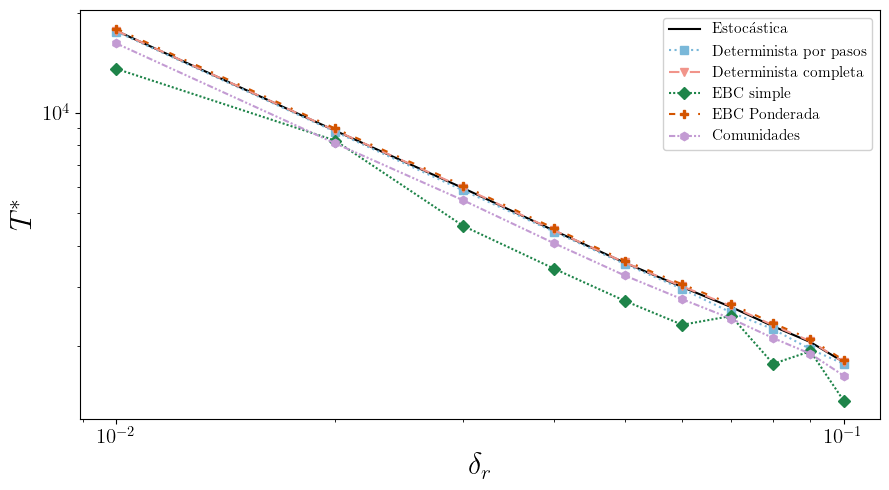

In [10]:
# -----------------------------------CÁLCULO T*--------------------------------------

umbral = 0.99

# Tomar las keys directamente del primer dataset (todas tienen las mismas)
deltas_r = np.array(sorted(Estocastica.keys()))

T_stars = {}

for nombre, data in datasets.items():
    keys = np.array(sorted(data.keys()))  # keys reales de cada dict
    T_stars[nombre] = []
    for key in keys:
        arr     = data[key]
        indices = np.where(arr >= umbral)[0]
        T_stars[nombre].append(indices[0] if len(indices) > 0 else np.nan)
    T_stars[nombre] = np.array(T_stars[nombre])

# -----------------------------------GRÁFICA--------------------------------------

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

for nombre, T_star in T_stars.items():
    est = estilos[nombre]
    ax.loglog(deltas_r, T_star,
            color=est['color'], marker=est['marker'], linestyle=est['linestyle'],
            linewidth=1.5, markersize=6, label=nombre)

ax.set_xlabel(r"$\delta_r$", fontsize=22)
ax.set_ylabel(r"$T^*$",      fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

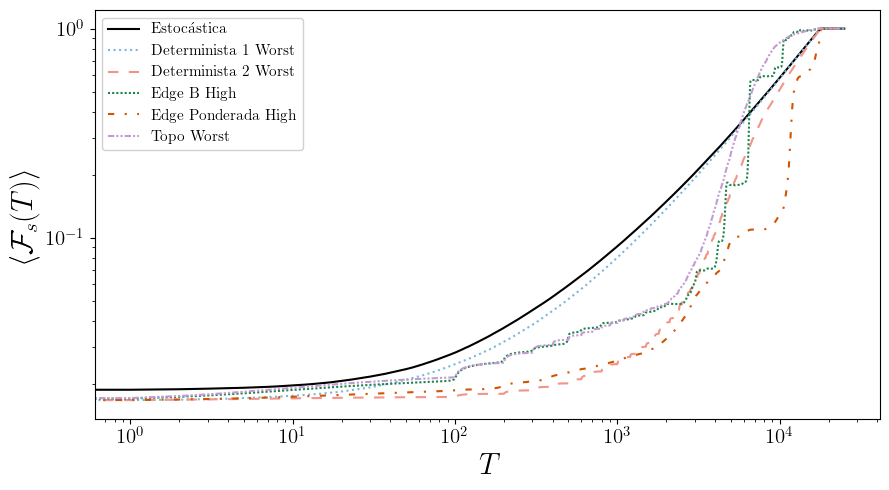

In [6]:
# --- PARÁMETROS ---
T_repair = 25000
delta_r  = 0.01

t_repair = np.arange(T_repair + 1)

# --- FIGURA ---
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

# --- CURVAS ---
for nombre, data in datasets.items():
    # Buscar la key más cercana a delta_r
    key = min(data.keys(), key=lambda k: abs(k - delta_r))
    est = estilos[nombre]
    ax.loglog(t_repair, data[key],
              color=est['color'], linestyle=est['linestyle'],
              linewidth=1.5, label=nombre)

# --- ETIQUETAS ---
ax.set_xlabel(r"$T$",                                        fontsize=22)
ax.set_ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

## SELECCIONADAS

In [3]:
# -----------------------------------DATOS--------------------------------------

datasets = {
    'Estocástica':           Estocastica,
    'Determinista por pasos':  Determinista1_Worst,
    'Determinista completa':  Determinista2_Worst,
    'EBC simple':           Edge_B_High,
    'EBC Ponderada':   Edge_Ponderada_High,
    'Comunidades':            Topo_Worst,
}

estilos = {

    'Estocástica': dict(
        color='black',
        linestyle='-',
        marker='o'
    ),

    'Determinista por pasos': dict(
        color='#0072B2',
        linestyle='--',
        marker='s'
    ),

    'Determinista completa': dict(
        color='#D55E00',
        linestyle='-.',
        marker='^'
    ),

    'EBC simple': dict(
        color='#009E73',
        linestyle=':',
        marker='D'
    ),

    'EBC Ponderada': dict(
        color='#CC79A7',
        linestyle=(0,(5,1)),
        marker='P'
    ),

    'Comunidades': dict(
        color='#E69F00',
        linestyle=(0,(3,1,1,1)),
        marker='X'
    ),
}

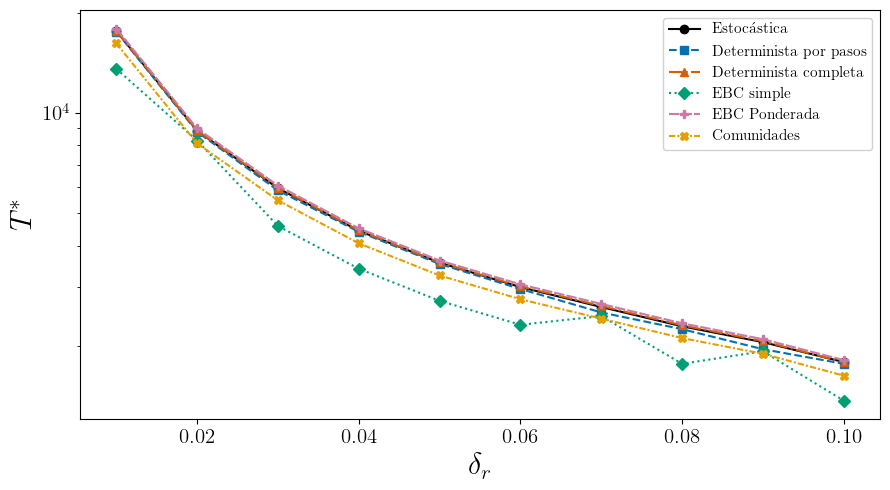

In [18]:
# -----------------------------------CÁLCULO T*--------------------------------------

umbral = 0.99

# Tomar las keys directamente del primer dataset (todas tienen las mismas)
deltas_r = np.array(sorted(Estocastica.keys()))

T_stars = {}

for nombre, data in datasets.items():
    keys = np.array(sorted(data.keys()))  # keys reales de cada dict
    T_stars[nombre] = []
    for key in keys:
        arr     = data[key]
        indices = np.where(arr >= umbral)[0]
        T_stars[nombre].append(indices[0] if len(indices) > 0 else np.nan)
    T_stars[nombre] = np.array(T_stars[nombre])

# -----------------------------------GRÁFICA--------------------------------------

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

for nombre, T_star in T_stars.items():
    est = estilos[nombre]
    ax.semilogy(deltas_r, T_star,
            color=est['color'], marker=est['marker'], linestyle=est['linestyle'],
            linewidth=1.5, markersize=6, label=nombre)

ax.set_xlabel(r"$\delta_r$", fontsize=22)
ax.set_ylabel(r"$T^*$",      fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

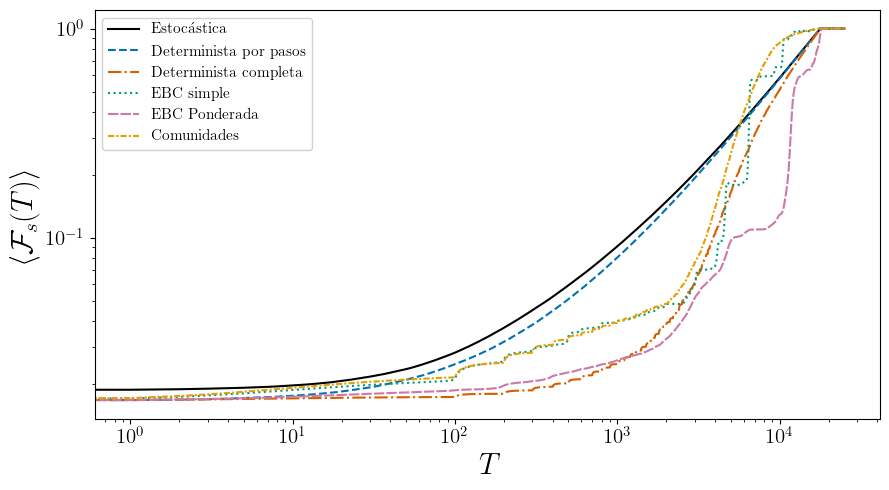

In [19]:
# --- PARÁMETROS ---
T_repair = 25000
delta_r  = 0.01

t_repair = np.arange(T_repair + 1)

# --- FIGURA ---
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

# --- CURVAS ---
for nombre, data in datasets.items():
    # Buscar la key más cercana a delta_r
    key = min(data.keys(), key=lambda k: abs(k - delta_r))
    est = estilos[nombre]
    ax.loglog(t_repair, data[key],
              color=est['color'], linestyle=est['linestyle'],
              linewidth=1.5, label=nombre)

# --- ETIQUETAS ---
ax.set_xlabel(r"$T$",                                        fontsize=22)
ax.set_ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

C:\Users\Kevin\AppData\Local\Temp\ipykernel_12704\1192892656.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


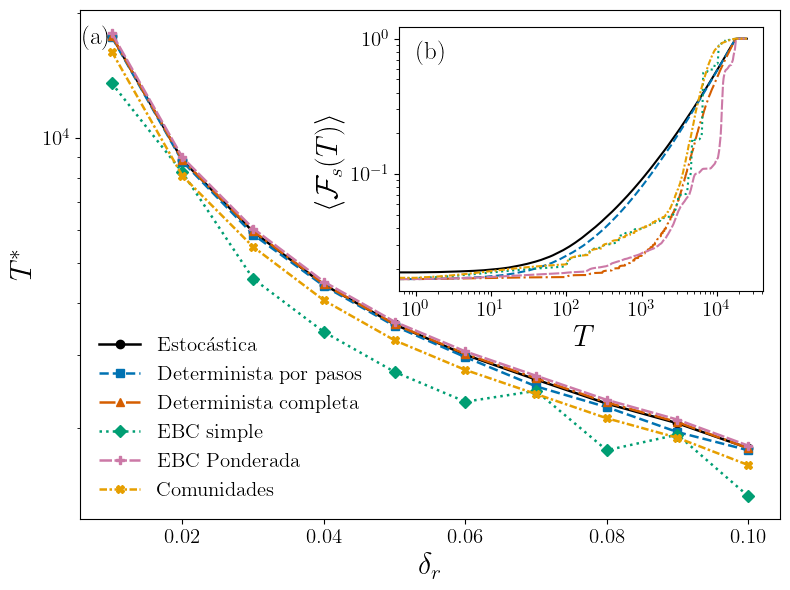

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# PARÁMETROS
# ==========================================================

T_repair = 25000
delta_r = 0.01
umbral = 0.99

t_repair = np.arange(T_repair + 1)

# Valores de delta_r
deltas_r = np.array(sorted(Estocastica.keys()))

# ==========================================================
# CÁLCULO DE T*
# ==========================================================

T_stars = {}

for nombre, data in datasets.items():

    keys = np.array(sorted(data.keys()))
    T_stars[nombre] = []

    for key in keys:

        arr = data[key]
        indices = np.where(arr >= umbral)[0]

        if len(indices) > 0:
            T_stars[nombre].append(indices[0])
        else:
            T_stars[nombre].append(np.nan)

    T_stars[nombre] = np.array(T_stars[nombre])

# ==========================================================
# FIGURA
# ==========================================================

fig, ax1 = plt.subplots(figsize=(8,6), facecolor="white")

# ==========================================================
# (a) T* vs delta_r
# ==========================================================

for nombre, T_star in T_stars.items():

    est = estilos[nombre]

    ax1.semilogy(
        deltas_r,
        T_star,
        color=est["color"],
        marker=est["marker"],
        linestyle=est["linestyle"],
        linewidth=1.8,
        markersize=6,
        label=nombre
    )

ax1.set_xlabel(r"$\delta_r$", fontsize=22)
ax1.set_ylabel(r"$T^{*}$", fontsize=22)

ax1.tick_params(axis="both", labelsize=15)

ax1.text(
    0.005,
    0.97,
    "(a)",
    transform=ax1.transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
)

# ==========================================================
# LEYENDA
# ==========================================================

ax1.legend(
    loc="lower left",
    fontsize=15,
    frameon=False
)

# ==========================================================
# INSET (b)
# ==========================================================

ax2 = inset_axes(
    ax1,
    width="52%",
    height="52%",
    loc="upper right",
    borderpad=1.2
)

for nombre, data in datasets.items():

    key = min(
        data.keys(),
        key=lambda k: abs(k-delta_r)
    )

    est = estilos[nombre]

    ax2.loglog(
        t_repair,
        data[key],
        color=est["color"],
        linestyle=est["linestyle"],
        linewidth=1.5
    )

ax2.set_xlabel(r"$T$", fontsize=22)
ax2.set_ylabel(
    r"$\langle\mathcal{F}_s(T)\rangle$",
    fontsize=22
)

ax2.tick_params(
    axis="both",
    labelsize=15
)

ax2.text(
    0.05,
    0.95,
    "(b)",
    transform=ax2.transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
)

# ==========================================================
# GUARDAR
# ==========================================================

plt.tight_layout()

plt.savefig(
    "Comparacion_F.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()